In [59]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt

In [68]:
# 2. Data analysis and preprocessing.
df_diamond = pd.read_csv('./noisy_datasets/diamond.csv', index_col=False)
df_diamond_preprocessed = df_diamond.drop(columns=['Unnamed: 0', 'average us salary', 'number of diamonds mined (millions)'])
df_diamond_preprocessed = df_diamond_preprocessed.dropna(axis=0)
df_diamond_preprocessed = df_diamond_preprocessed[df_diamond_preprocessed.isin(['TRUE', 'FALSE', 'MAYBE']).any(axis=1) == False]
df_diamond_preprocessed['cut'] = df_diamond_preprocessed['cut'].replace({'IDEAL': 'Ideal', 'VERY GOOD': 'Very Good', 'GOOD': 'Good', 'very good': 'Very Good', 'ideal': 'Ideal', 'premium': 'Premium', 'PREMIUM': 'Premium', 'good': 'Good', 'FAIR': 'Fair'})
df_diamond_preprocessed['color'] = df_diamond_preprocessed['color'].replace({'e': 'E', 'i': 'I', 'j': 'J', 'h': 'H', 'g': 'G', 'd': 'D', 'f': 'F'})
df_diamond_preprocessed['clarity'] = df_diamond_preprocessed['clarity'].replace({'si2': 'SI2', 'vvs2': 'VVS2', 'si1': 'SI1', 'vs2': 'VS2', 'vs1': 'VS1'})
df_diamond_preprocessed['carat'] = df_diamond_preprocessed['carat'].astype('float64')
df_diamond_preprocessed['depth'] = df_diamond_preprocessed['depth'].astype('float64')
df_diamond_preprocessed['table'] = df_diamond_preprocessed['table'].astype('float64')
df_diamond_preprocessed['price'] = df_diamond_preprocessed['price'].astype('float64')
df_diamond_preprocessed['x'] = df_diamond_preprocessed['x'].astype('float64')
df_diamond_preprocessed['y'] = df_diamond_preprocessed['y'].astype('float64')
df_diamond_preprocessed['z'] = df_diamond_preprocessed['z'].astype('float64')

In [69]:
object_columns = df_diamond_preprocessed.select_dtypes(include=['object'])
for col in object_columns:
    df_diamond_preprocessed[col] = df_diamond_preprocessed[col].astype('category')
df_diamond_preprocessed = pd.get_dummies(df_diamond_preprocessed, drop_first=False)
bool_columns = df_diamond_preprocessed.select_dtypes(include=['bool'])
for col in bool_columns:
    df_diamond_preprocessed[col] = df_diamond_preprocessed[col].astype('int')

In [70]:
df_diamond_preprocessed.info

<bound method DataFrame.info of        carat  depth  table   price     x     y     z  cut_Fair  cut_Good  \
0       0.23   61.5   55.0   326.0  3.95  3.98  2.43         0         0   
1       0.21   59.8   61.0   326.0  3.89  3.84  2.31         0         0   
2       0.23   56.9   65.0   327.0  4.05  4.07  2.31         0         1   
3       0.29   62.4   58.0   334.0  4.20  4.23  2.63         0         0   
4       0.31   63.3   58.0   335.0  4.34  4.35  2.75         0         1   
...      ...    ...    ...     ...   ...   ...   ...       ...       ...   
53935   0.72   60.8   57.0  2757.0  5.75  5.76  3.50         0         0   
53936   0.72   63.1   55.0  2757.0  5.69  5.75  3.61         0         1   
53937   0.70   62.8   60.0  2757.0  5.66  5.68  3.56         0         0   
53938   0.86   61.0   58.0  2757.0  6.15  6.12  3.74         0         0   
53939   0.75   62.2   55.0  2757.0  5.83  5.87  3.64         0         0   

       cut_Ideal  ...  color_I  color_J  clarity_I1  cl

In [71]:
# 3. Data preparation (y: price)
warnings.filterwarnings('ignore')
df_diamond_shuffled = df_diamond_preprocessed.sample(frac=1).reset_index(drop=True)
split_index = int(0.8 * len(df_diamond_shuffled))

X = df_diamond_shuffled.drop(columns=['price'])
y = df_diamond_shuffled['price']

X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(39047, 26) (39047,) (9762, 26) (9762,)


In [72]:
num_columns = X_train.select_dtypes(include=['int64', 'float64'])
for col in num_columns:
    min_value = X_train[col].min()
    max_value = X_train[col].max()
    X_train[col] = (X_train[col] - min_value) / (max_value - min_value)

In [64]:
# 4, 5
def elastic_net(X, y, lambda1, lambda2, lr=0.01, n_iter=1000):
    n, d = X.shape
    w = np.zeros(d)  # Initialize weights
    b = 0
    
    for i in range(n_iter):
        y_pred = np.dot(X, w)
        
        dw = (1 / n) * np.dot(X.T, (y_pred - y)) + lambda1 * np.sign(w) + 2 * lambda2 * w
        db = (1 / n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db
    
    return w, b

lambda1 = [0.01, 0.1, 1, 10, 100]
lambda2 = [0.01, 0.1, 1, 10, 100]
learning_rate = 0.001
n_iterations = 10000

# Predictions
def predict(w, X, b):
    return np.dot(X, w) + b

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# To decide lambda value
for l1 in lambda1:
    for l2 in lambda2:
        weights, bias = elastic_net(X_train, y_train, l1, l2, lr=learning_rate, n_iter=n_iterations)
        pred_elastic_net = predict(weights, X_test, bias)
        error = mse(y_test, pred_elastic_net)
        print(f'Lambda: {l1}, {l2}, Validation MSE: {error}')


In [ ]:
# To decide learning rate and the number of iterations.

In [13]:
weights1, bias1 = elastic_net(X_train, y_train, 100, 100, lr=0.001, n_iter=100000)
pred_elastic_net1 = predict(weights1, X_test, bias1)
error1 = mse(y_test, pred_elastic_net1)
print(f'Learning rate: 0.001, Iterations: 100000, Validation MSE: {error}')

Learning rate: 0.001, Iterations: 100000, Validation MSE: 5209369304.944361


In [17]:
weights2, bias2 = elastic_net(X_train, y_train, 100, 100, lr=0.001, n_iter=50000)
pred_elastic_net2 = predict(weights2, X_test, bias2)
error2 = mse(y_test, pred_elastic_net2)
print(f'Learning rate: 0.001, Iterations: 50000, Validation MSE: {error2}')

Learning rate: 0.001, Iterations: 50000, Validation MSE: 36883792428.27088


In [16]:
weights3, bias3 = elastic_net(X_train, y_train, 100, 100, lr=0.001, n_iter=10000)
pred_elastic_net3 = predict(weights3, X_test, bias3)
error3 = mse(y_test, pred_elastic_net3)
print(f'Learning rate: 0.001, Iterations: 10000, Validation MSE: {error3}')

Learning rate: 0.001, Iterations: 10000, Validation MSE: 1322486910.9337482


In [18]:
weights4, bias4 = elastic_net(X_train, y_train, 100, 100, lr=0.01, n_iter=10000)
pred_elastic_net4 = predict(weights4, X_test, bias4)
error4 = mse(y_test, pred_elastic_net4)
print(f'Learning rate: 0.01, Iterations: 10000, Validation MSE: {error4}')

Learning rate: 0.01, Iterations: 10000, Validation MSE: 8.360360510510841e+148


In [37]:
# 6. Experiment with at least three different methods for initializing weights
from math import sqrt
def xavier_initialization(input_dim, output_dim):
    # Calculate the limit for uniform distribution
    limit = sqrt(6 / (input_dim + output_dim))
    # Initialize weights with uniform distribution in the range [-limit, limit]
    weights = np.random.uniform(-limit, limit, size=(input_dim, output_dim))
    return weights

def elastic_net_w(X, y, lambda1, lambda2, lr=0.01, n_iter=1000, w_type='zero'):
    n, d = X.shape
    if w_type == 'zero':
        w = np.zeros(d)
    elif w_type == 'random':
        w = np.random.randn(d)
    elif w_type == 'xavier':
        w = xavier_initialization(d, 1).flatten()
    b = 0
    
    for i in range(n_iter):
        y_pred = np.dot(X, w)
        
        dw = (1 / n) * np.dot(X.T, (y_pred - y)) + lambda1 * np.sign(w) + 2 * lambda2 * w
        db = (1 / n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

    
    return w, b

lambda1 = 100
lambda2 = 100
learning_rate = 0.001
max_iterations = 10000

weights_zero, bias_zero = elastic_net_w(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations, w_type = 'zero')
weights_random, bias_random = elastic_net_w(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations, w_type = 'random')
weights_xavier, bias_xavier = elastic_net_w(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations, w_type = 'xavier')

pred_zero = predict(weights_zero, X_test, bias_zero)
pred_random = predict(weights_random, X_test, bias_random)
pred_xavier = predict(weights_xavier, X_test, bias_xavier)
error_zero = mse(y_test, pred_zero)
error_random = mse(y_test, pred_random)
error_xavier = mse(y_test, pred_xavier)
print(f'weights_zero, Validation MSE: {error_zero}')
print(f'weights_random, Validation MSE: {error_random}')
print(f'weights_xavier, Validation MSE: {error_xavier}')

weights_zero, Validation MSE: 1322486910.9337482
weights_random, Validation MSE: 1322486918.6690648
weights_xavier, Validation MSE: 1322486978.138637


In [80]:
# 7. Experiment with training stoplambda1 = 0.01
def elastic_net_tol(X, y, lambda1, lambda2, lr=0.01, n_iter=1000, tol=10000):
    n, d = X.shape
    w = np.zeros(d)
    b = 0
    
    for i in range(n_iter):
        y_pred = np.dot(X, w)
        
        dw = (1 / n) * np.dot(X.T, (y_pred - y)) + lambda1 * np.sign(w) + 2 * lambda2 * w
        db = (1 / n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        if np.all(np.abs(dw) < tol) and np.abs(db) < tol:
            break
    
    return w, b

lambda1 = 100
lambda2 = 100
learning_rate = 0.001
max_iterations = 10000
tolerance = 0.01

# 1: Using fixed number of iterations
weights_fixed, bias_fixed = elastic_net(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations)

# 2: Using gradient threshold
weights_tol, bias_tol = elastic_net_tol(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations, tol=tolerance)

pred_fixed = predict(weights_fixed, X_test, bias_fixed)
pred_tol = predict(weights_tol, X_test, bias_tol)
error_fixed = mse(y_test, pred_fixed)
error_tol = mse(y_test, pred_tol)
print(f'pred_fixed, Validation MSE: {error_fixed}')
print(f'pred_tol, Validation MSE: {error_tol}')

pred_fixed, Validation MSE: 1330389342.1942549
pred_tol, Validation MSE: 1330389342.1942549


In [73]:
def elastic_net_best(X, y, lambda1, lambda2, lr=0.01, n_iter=1000):
    n, d = X.shape
    w = np.zeros(d)
    b = 0
    loss_history = []
    for i in range(n_iter):
        y_pred = np.dot(X, w)
        
        dw = (1 / n) * np.dot(X.T, (y_pred - y)) + lambda1 * np.sign(w) + 2 * lambda2 * w
        db = (1 / n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        mse_loss = (1 / (2 * n)) * np.sum((y_pred - y) ** 2)
        l1_loss = lambda1 * np.sum(np.abs(w))
        l2_loss = lambda2 * np.sum(w ** 2)
        loss = mse_loss + l1_loss + l2_loss
        loss_history.append(loss)

    return w, b, loss_history

lambda1 = 100
lambda2 = 100
learning_rate = 0.001
max_iterations = 10000

weights_best, bias_best, loss_history = elastic_net_best(X_train, y_train, lambda1, lambda2, lr=learning_rate, n_iter=max_iterations)
pred_best = predict(weights_best, X_test, bias_best)

In [74]:
weights_dic = {'weights': weights_best, 'bias': bias_best}
print(weights_dic)
with open('heejuhwa_assignment1_part4.pickle', 'wb') as file:
    pickle.dump(weights_dic, file)

{'weights': array([ 3.75848563,  9.69130458,  4.77599782, 11.79878294,  1.74282828,
        9.61039506,  0.16626627,  1.27072746,  6.3290325 ,  5.38073358,
        3.92918423,  1.46410422,  2.27942916,  2.76440611,  3.6874392 ,
        2.97806596,  2.04310006,  0.85939932, -0.04463958,  0.10743054,
        4.32323272,  3.81500734,  2.41160491,  3.94848995,  0.36811342,
        0.97250534]), 'bias': 39152.02890235671}


In [75]:
print(loss_history[0], loss_history[-1])

15780785.243468078 15720729.098668281


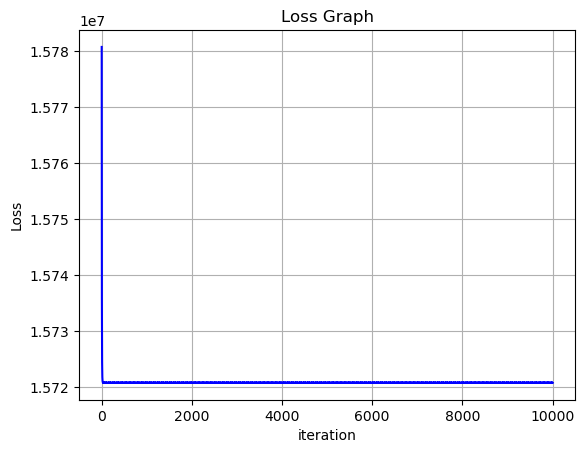

In [76]:
x = [x+1 for x in range(len(loss_history)) ]
plt.plot(x, loss_history, linestyle='-', color='b')
plt.title('Loss Graph')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

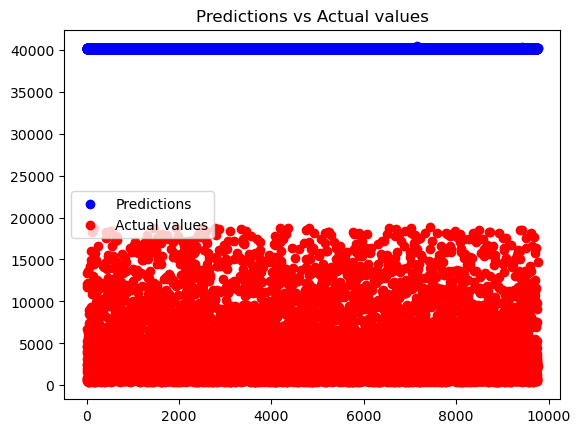

In [77]:
n = y_test.shape[0]
plt.scatter([x for x in range(1, n+1)], pred_best, color='blue', label='Predictions')
plt.scatter([x for x in range(1, n+1)], y_test, color='red', label='Actual values')

plt.title('Predictions vs Actual values')
plt.legend()
plt.show()

Reference

* preprocessing code from Part I
* data split code from Part II
* regression code from Part III
* https://numpy.org/doc/stable/reference/generated/numpy.matrix.transpose.html
* https://numpy.org/doc/stable/reference/routines.linalg.html#module-numpy.linalg
* https://docs.python.org/3/library/pickle.html
*   